In [2]:
# ==============================================================================
# LANGKAH 1: IMPORT LIBRARY YANG DIPERLUKAN
# ==============================================================================

# Library untuk manipulasi dan analisis data
import pandas as pd
import numpy as np

# Library untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk machine learning (scikit-learn)
from sklearn.model_selection import train_test_split          # Membagi data
from sklearn.ensemble import RandomForestClassifier           # Model utama
from sklearn.metrics import (accuracy_score,                  # Akurasi
                             confusion_matrix,                # Confusion matrix
                             classification_report,           # Laporan klasifikasi
                             ConfusionMatrixDisplay)          # Visualisasi CM

# Mengabaikan peringatan agar output lebih bersih
import warnings
warnings.filterwarnings('ignore')

# Mengatur tampilan tabel pandas agar lebih rapi
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


In [4]:
from google.colab import files
uploaded = files.upload()

Saving data_testing.csv to data_testing.csv
Saving data_training.csv to data_training.csv


In [6]:
# ==============================================================================
# LANGKAH 2: LOAD DATASET
# ==============================================================================
# Load dataset training (memiliki kolom target 'quality')
df_train = pd.read_csv('data_training.csv')

# Load dataset testing (tidak memiliki kolom 'quality')
df_test = pd.read_csv('data_testing.csv')

print(f"Dataset training berhasil dimuat  → {df_train.shape[0]} baris, {df_train.shape[1]} kolom")
print(f"Dataset testing  berhasil dimuat  → {df_test.shape[0]} baris, {df_test.shape[1]} kolom")

Dataset training berhasil dimuat  → 857 baris, 13 kolom
Dataset testing  berhasil dimuat  → 286 baris, 12 kolom


**EKSPLORASI DATA (EDA)**

In [14]:
# ==============================================================================
# LANGKAH 3: EKSPLORASI DATA (EDA)
# ==============================================================================

print("\n" + "="*60)
print("  3A. TAMPILAN AWAL DATA TRAINING (head)")
print("="*60)
# Menampilkan 5 baris pertama untuk melihat bentuk data
print(df_train.head())


  3A. TAMPILAN AWAL DATA TRAINING (head)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  \
0            7.3             0.740         0.08             1.7      0.094                 10.0                  45.0   
1            8.1             0.575         0.22             2.1      0.077                 12.0                  65.0   
2           10.1             0.430         0.40             2.6      0.092                 13.0                  52.0   
3           12.9             0.500         0.55             2.8      0.072                  7.0                  24.0   
4            8.4             0.360         0.32             2.2      0.081                 32.0                  79.0   

   density    pH  sulphates  alcohol  quality    Id  
0  0.99576  3.24       0.50      9.8        5  1366  
1  0.99670  3.29       0.51      9.2        5   103  
2  0.99834  3.22       0.64     10.0        7   942  
3  1.00012  3.0

In [15]:
print("\n" + "="*60)
print("  3B. TAMPILAN AWAL DATA TESTING (head)")
print("="*60)
print(df_test.head())


  3B. TAMPILAN AWAL DATA TESTING (head)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  \
0            6.8              0.61         0.04             1.5      0.057                  5.0                  10.0   
1            6.9              0.84         0.21             4.1      0.074                 16.0                  65.0   
2            7.0              0.58         0.12             1.9      0.091                 34.0                 124.0   
3            7.8              0.48         0.68             1.7      0.415                 14.0                  32.0   
4           12.5              0.60         0.49             4.3      0.100                  5.0                  14.0   

   density    pH  sulphates    alcohol    Id  
0  0.99525  3.42       0.60   9.500000   222  
1  0.99842  3.53       0.72   9.233333  1514  
2  0.99560  3.44       0.48  10.500000   417  
3  0.99656  3.09       1.06   9.100000   754

In [13]:
print("\n" + "="*60)
print("  3C. INFORMASI TIPE DATA & JUMLAH NON-NULL (info)")
print("="*60)
# Menampilkan informasi kolom, tipe data, dan jumlah nilai non-null
print("--- DATA TRAINING ---")
df_train.info()

print("\n--- DATA TESTING ---")
df_test.info()


  3C. INFORMASI TIPE DATA & JUMLAH NON-NULL (info)
--- DATA TRAINING ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB

---

In [10]:
print("\n" + "="*60)
print("  3D. STATISTIK DESKRIPTIF (describe)")
print("="*60)
# Menampilkan ringkasan statistik: mean, std, min, max, kuartil
print("--- DATA TRAINING ---")
print(df_train.describe().round(3))


  3D. STATISTIK DESKRIPTIF (describe)
--- DATA TRAINING ---
       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  \
count        857.000           857.000      857.000         857.000    857.000              857.000   
mean           8.262             0.529        0.267           2.506      0.087               15.783   
std            1.702             0.179        0.195           1.294      0.049               10.300   
min            4.600             0.120        0.000           0.900      0.012                1.000   
25%            7.100             0.395        0.090           1.900      0.070                7.000   
50%            7.900             0.520        0.250           2.200      0.079               14.000   
75%            9.100             0.640        0.420           2.600      0.090               21.000   
max           15.600             1.580        1.000          15.500      0.611               68.000   

       tota

In [11]:
print("\n" + "="*60)
print("  3E. CEK MISSING VALUE")
print("="*60)
# Menghitung jumlah nilai kosong (NaN) di setiap kolom
missing_train = df_train.isnull().sum()
missing_test  = df_test.isnull().sum()

print("Missing value pada DATA TRAINING:")
print(missing_train)
print(f"\nTotal missing value training : {missing_train.sum()}")

print("\nMissing value pada DATA TESTING:")
print(missing_test)
print(f"Total missing value testing  : {missing_test.sum()}")


  3E. CEK MISSING VALUE
Missing value pada DATA TRAINING:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Total missing value training : 0

Missing value pada DATA TESTING:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64
Total missing value testing  : 0


**VISUALISASI DATA**


 Membuat visualisasi distribusi kualitas wine...


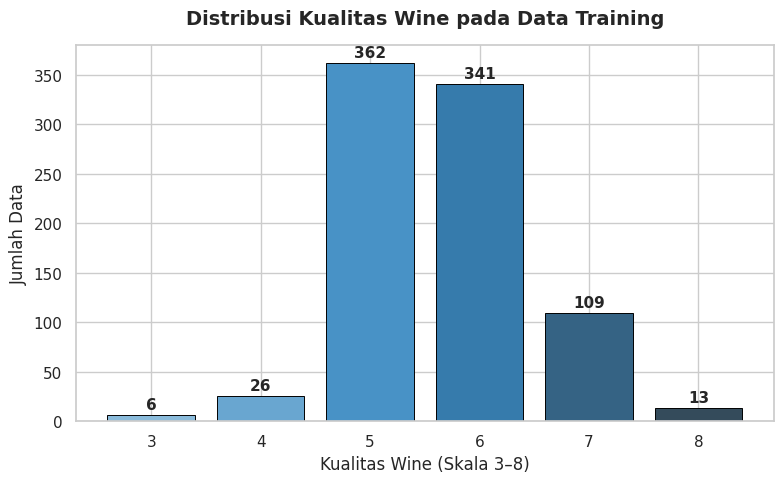

In [17]:
# ==============================================================================
# LANGKAH 4: VISUALISASI DATA
# ==============================================================================

# Mengatur tema seaborn agar grafik terlihat lebih bersih
sns.set_theme(style="whitegrid", palette="muted")

# ------------------------------------------------------------------
# 4A. DISTRIBUSI KUALITAS WINE (Countplot)
# ------------------------------------------------------------------
print("\n Membuat visualisasi distribusi kualitas wine...")

fig, ax = plt.subplots(figsize=(8, 5))

# Menghitung frekuensi tiap kelas kualitas
quality_counts = df_train['quality'].value_counts().sort_index()

# Membuat countplot dengan warna berbeda per kelas
bars = ax.bar(quality_counts.index, quality_counts.values,
              color=sns.color_palette("Blues_d", len(quality_counts)),
              edgecolor='black', linewidth=0.7)

# Menambahkan label angka di atas setiap batang
for bar, count in zip(bars, quality_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 3,
            str(count),
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Distribusi Kualitas Wine pada Data Training', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Kualitas Wine (Skala 3–8)', fontsize=12)
ax.set_ylabel('Jumlah Data', fontsize=12)
ax.set_xticks(quality_counts.index)
plt.tight_layout()
plt.savefig('plot_distribusi_quality.png', dpi=150, bbox_inches='tight')
plt.show()

 INTERPRETASI Distribusi Kualitas:
   - Kualitas wine berkisar antara 3 hingga 8 (skala 1–10).
   - Kelas 5 dan 6 mendominasi dataset (imbalanced class).
   - Kelas 3 dan 8 sangat sedikit (minoritas), sehingga model
     mungkin kurang akurat dalam memprediksi kelas ekstrem ini.
   - Kondisi ini disebut class imbalance dan perlu diperhatikan
     saat mengevaluasi model.

Membuat heatmap korelasi...


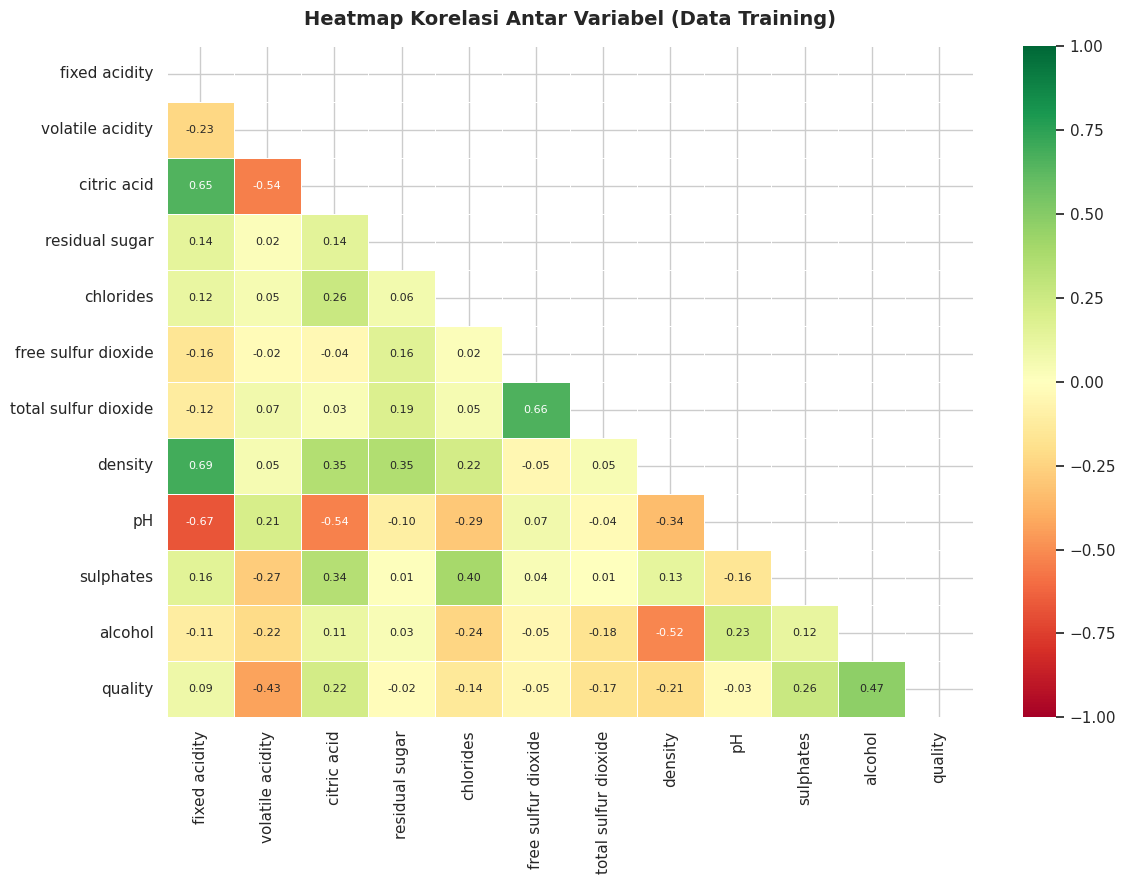

In [19]:
# ------------------------------------------------------------------
# 4B. HEATMAP KORELASI ANTAR VARIABEL
# ------------------------------------------------------------------
print("Membuat heatmap korelasi...")

# Menghitung matriks korelasi (hanya kolom numerik, kecuali Id)
cols_for_corr = [c for c in df_train.columns if c != 'Id']
corr_matrix = df_train[cols_for_corr].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Sembunyikan segitiga atas (duplikat)

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,          # Tampilkan nilai korelasi
            fmt='.2f',           # Format 2 desimal
            cmap='RdYlGn',       # Warna merah-kuning-hijau
            vmin=-1, vmax=1,
            linewidths=0.5,
            ax=ax,
            annot_kws={'size': 8})

ax.set_title('Heatmap Korelasi Antar Variabel (Data Training)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

 INTERPRETASI Heatmap Korelasi:
   - Alcohol memiliki korelasi positif tertinggi dengan quality (+),
     artinya wine dengan kadar alkohol lebih tinggi cenderung berkualitas lebih baik.
   - Volatile acidity berkorelasi negatif dengan quality,
     artinya kadar asam volatil tinggi menurunkan kualitas wine.
   - Density dan fixed acidity berkorelasi tinggi satu sama lain
     (multikolinearitas), namun Random Forest tahan terhadap hal ini.
   - Fitur dengan korelasi rendah terhadap quality tidak berarti tidak
     berguna—kombinasi fitur bisa tetap informatif untuk model.

Membuat boxplot distribusi fitur...


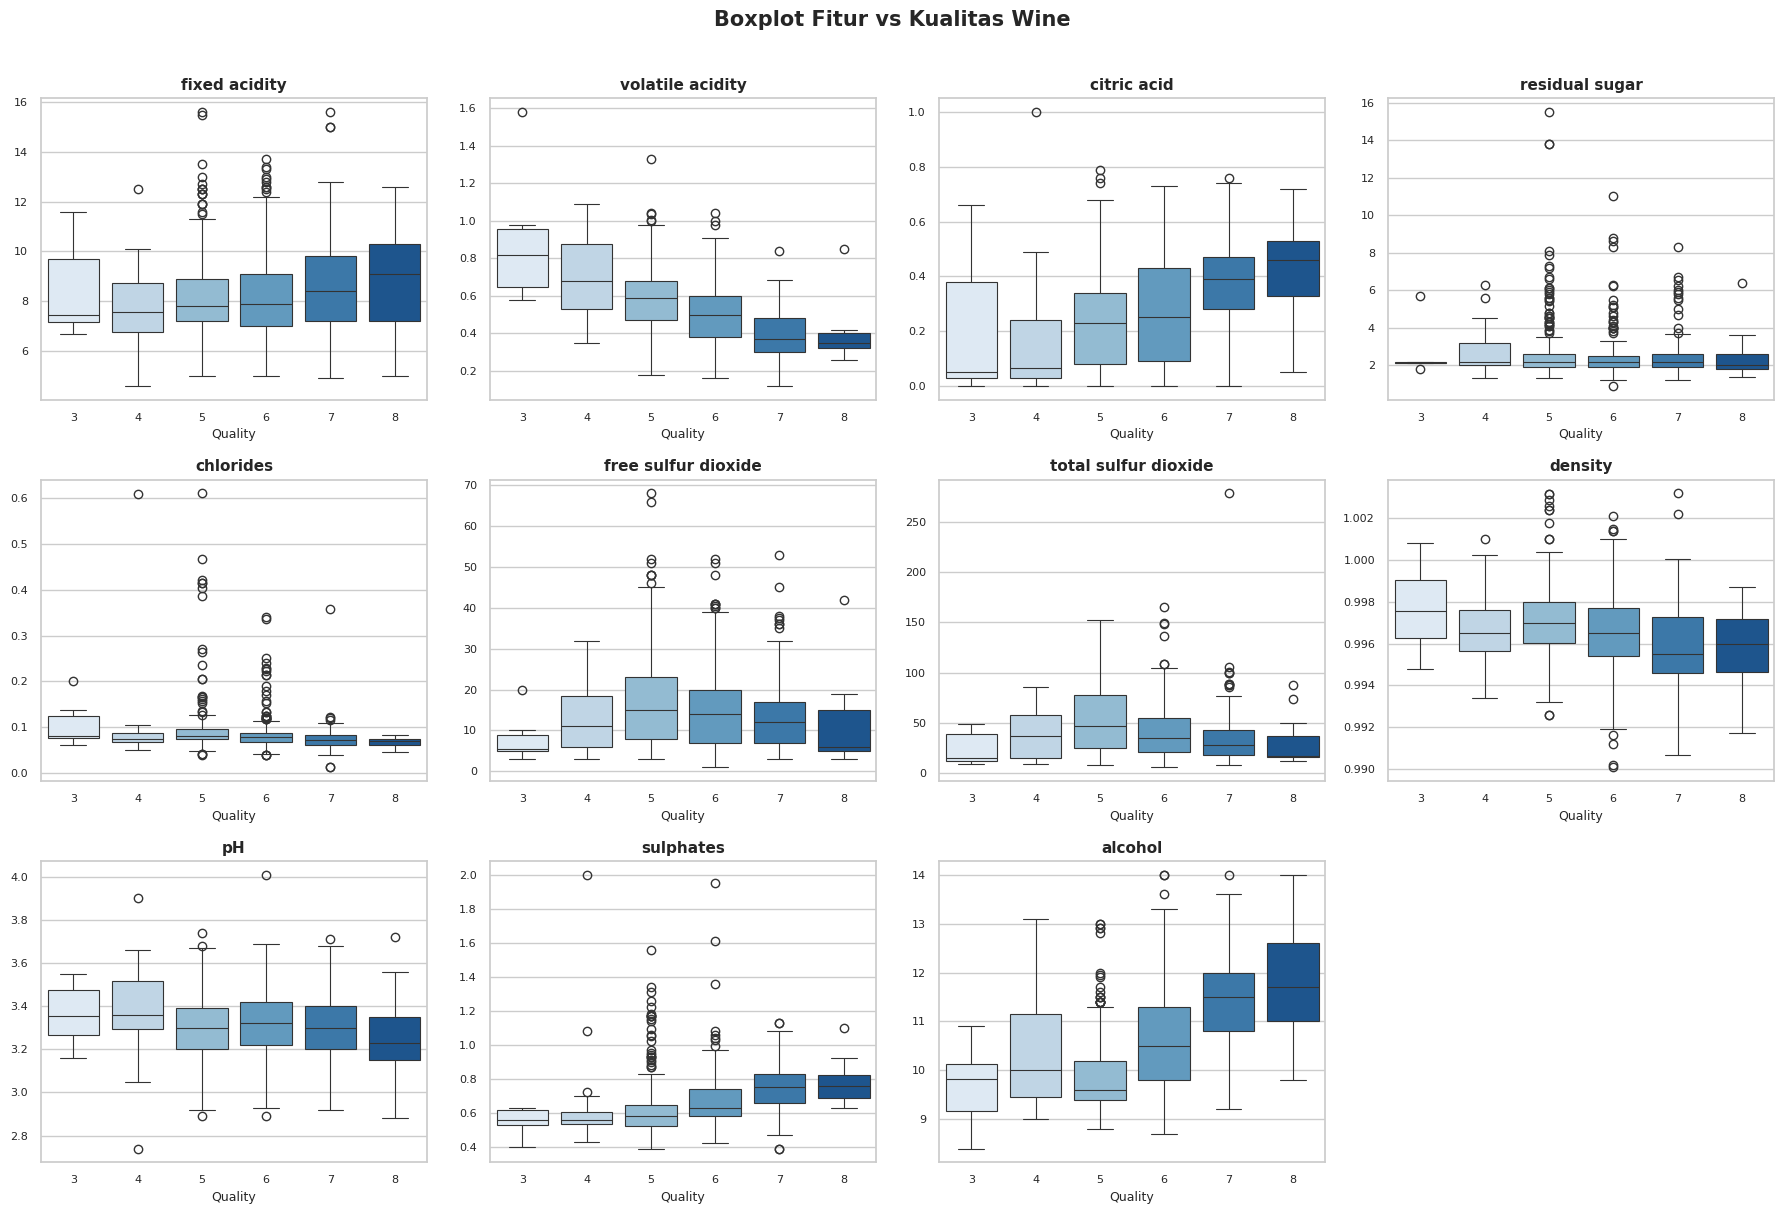

In [21]:
# ------------------------------------------------------------------
# 4C. BOXPLOT UNTUK MELIHAT DISTRIBUSI DAN OUTLIER
# ------------------------------------------------------------------
print("Membuat boxplot distribusi fitur...")

# Pilih kolom fitur numerik (kecuali Id dan quality)
feature_cols = [c for c in df_train.columns if c not in ['Id', 'quality']]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(data=df_train, x='quality', y=col,
                palette='Blues', ax=axes[i], linewidth=0.8)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Quality', fontsize=9)
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='both', labelsize=8)

# Sembunyikan subplot kosong jika ada
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplot Fitur vs Kualitas Wine', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_boxplot_fitur.png', dpi=150, bbox_inches='tight')
plt.show()

INTERPRETASI Boxplot:
   - Alcohol: wine berkualitas tinggi (7–8) cenderung memiliki kadar alkohol
     lebih tinggi, terlihat dari posisi box yang lebih tinggi.
   - Volatile acidity: wine berkualitas rendah (3–4) memiliki kadar lebih tinggi
     dan banyak outlier, menunjukkan kadar asam volatil mempengaruhi kualitas.
   - Sulphates: wine berkualitas lebih tinggi cenderung memiliki sulphates lebih
     tinggi secara rata-rata.
   - Banyak fitur memiliki outlier (titik di luar whisker) — ini wajar pada
     data kimia wine. Random Forest tidak sensitif terhadap outlier.

DATA CLEANING

In [27]:
# ==============================================================================
# LANGKAH 5: DATA CLEANING
# ==============================================================================
# --- 5A. Cek Missing Value ---
total_missing_train = df_train.isnull().sum().sum()
total_missing_test  = df_test.isnull().sum().sum()

print(f"\nTotal missing value pada data training : {total_missing_train}")
print(f"Total missing value pada data testing  : {total_missing_test}")

if total_missing_train == 0 and total_missing_test == 0:
    print("""
Kesimpulan: Tidak ada missing value pada kedua dataset.
Data sudah bersih dan siap digunakan untuk proses modeling.
Tidak diperlukan penanganan imputation atau penghapusan baris.
""")
else:
    # Jika ada missing value, isi dengan median (robust terhadap outlier)
    print("\nDitemukan missing value. Mengisi dengan nilai median...")
    numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        if df_train[col].isnull().sum() > 0:
            median_val = df_train[col].median()
            df_train[col].fillna(median_val, inplace=True)
            print(f"   - Kolom '{col}' diisi median = {median_val:.4f}")
    for col in df_test.select_dtypes(include=[np.number]).columns:
        if df_test[col].isnull().sum() > 0:
            median_val = df_train[col].median()  # Gunakan median dari training!
            df_test[col].fillna(median_val, inplace=True)
    print(" Missing value telah ditangani.")

# --- 5B. Cek duplikat ---
dup_train = df_train.duplicated().sum()
print(f"Jumlah baris duplikat pada training : {dup_train}")
if dup_train > 0:
    df_train = df_train.drop_duplicates()
    print(f"Duplikat dihapus. Sisa data: {df_train.shape[0]} baris")
else:
    print("Tidak ada duplikat.")


Total missing value pada data training : 0
Total missing value pada data testing  : 0

Kesimpulan: Tidak ada missing value pada kedua dataset.
Data sudah bersih dan siap digunakan untuk proses modeling.
Tidak diperlukan penanganan imputation atau penghapusan baris.

Jumlah baris duplikat pada training : 0
Tidak ada duplikat.


In [34]:
# ==============================================================================
# LANGKAH 6: PISAHKAN FITUR DAN TARGET
# ==============================================================================
print("\n" + "="*60)
print("  LANGKAH 6: PISAHKAN FITUR DAN TARGET")
print("="*60)

# Kolom 'Id' tidak digunakan untuk training (hanya identifier)
# Kolom 'quality' adalah target yang ingin diprediksi

# X = fitur (semua kolom kecuali 'quality' dan 'Id')
X = df_train.drop(columns=['quality', 'Id'])

# y = target (kolom 'quality')
y = df_train['quality']

print(f"\nFitur (X)  : {X.shape[1]} kolom → {list(X.columns)}")
print(f"Target (y) : kolom 'quality'")
print(f"Total data : {X.shape[0]} baris")
print(f"\nDistribusi kelas target:\n{y.value_counts().sort_index().to_string()}")


  LANGKAH 6: PISAHKAN FITUR DAN TARGET

Fitur (X)  : 11 kolom → ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Target (y) : kolom 'quality'
Total data : 857 baris

Distribusi kelas target:
quality
3      6
4     26
5    362
6    341
7    109
8     13


In [33]:
# ==============================================================================
# LANGKAH 7: SPLIT DATA TRAINING DAN VALIDATION
# ==============================================================================

print("\n" + "="*60)
print("  LANGKAH 7: SPLIT DATA TRAINING & VALIDATION")
print("="*60)

# Membagi data: 80% training, 20% validation
# random_state=42 agar hasil bisa direproduksi (reproducible)
# stratify=y agar proporsi kelas tetap seimbang di kedua subset
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,       # 20% untuk validasi
    random_state=42,     # Seed untuk reproduktibilitas
    stratify=y           # Mempertahankan proporsi kelas
)

print(f"\nData Training   : {X_train.shape[0]} baris ({X_train.shape[0]/X.shape[0]*100:.0f}%)")
print(f"Data Validasi   : {X_val.shape[0]} baris ({X_val.shape[0]/X.shape[0]*100:.0f}%)")
print(f"\nDistribusi kelas pada training:\n{y_train.value_counts().sort_index().to_string()}")
print(f"\nDistribusi kelas pada validasi:\n{y_val.value_counts().sort_index().to_string()}")


  LANGKAH 7: SPLIT DATA TRAINING & VALIDATION

Data Training   : 685 baris (80%)
Data Validasi   : 172 baris (20%)

Distribusi kelas pada training:
quality
3      5
4     21
5    289
6    273
7     87
8     10

Distribusi kelas pada validasi:
quality
3     1
4     5
5    73
6    68
7    22
8     3


In [44]:
# ==============================================================================
# LANGKAH 8: MEMBANGUN MODEL RANDOM FOREST CLASSIFIER
# ==============================================================================

# Membuat model Random Forest
# n_estimators = jumlah pohon keputusan (semakin banyak, semakin stabil)
# max_depth    = kedalaman maksimal setiap pohon (None = tidak dibatasi)
# random_state = seed untuk reproduktibilitas hasil
model_rf = RandomForestClassifier(
    n_estimators=200,      # 200 pohon keputusan
    max_depth=None,        # Kedalaman tidak dibatasi
    min_samples_split=2,   # Minimum sampel untuk split node
    min_samples_leaf=1,    # Minimum sampel di daun pohon
    random_state=42,       # Reproduktibilitas
    n_jobs=-1              # Gunakan semua CPU yang tersedia
)

In [45]:
# ==============================================================================
# LANGKAH 9: TRAINING MODEL
# ==============================================================================

# Melatih model menggunakan data training
model_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)


  LANGKAH 10: EVALUASI MODEL

Accuracy Score pada Data Validasi : 0.5988 (59.88%)

Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.65      0.79      0.72        73
           6       0.56      0.56      0.56        68
           7       0.46      0.27      0.34        22
           8       1.00      0.33      0.50         3

    accuracy                           0.60       172
   macro avg       0.45      0.33      0.35       172
weighted avg       0.57      0.60      0.58       172

Membuat visualisasi Confusion Matrix...


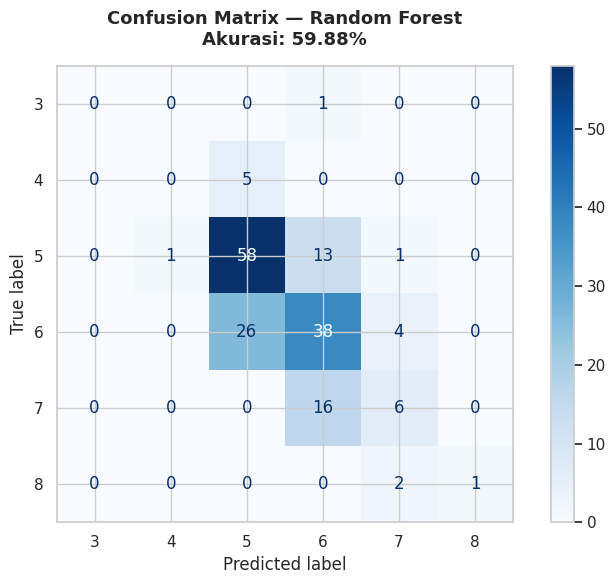

Membuat visualisasi Feature Importance...


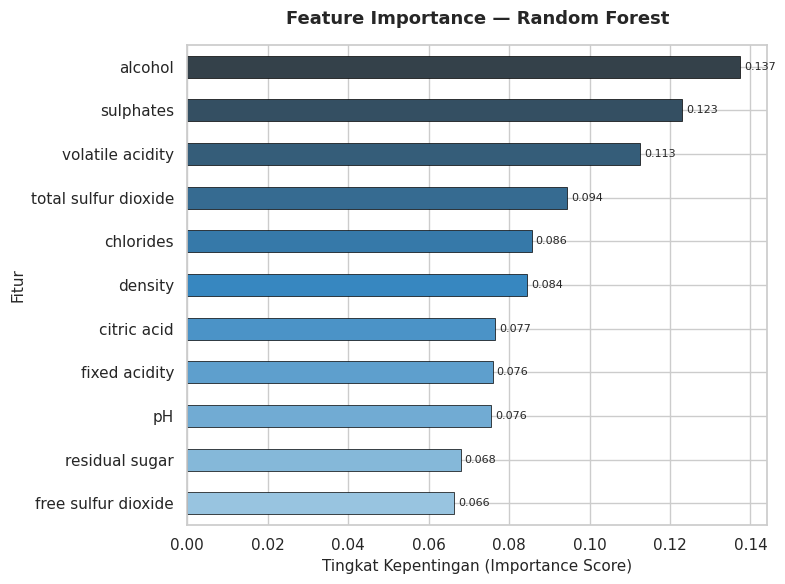


Fitur paling penting: alcohol (0.1374)
Fitur paling tidak penting: free sulfur dioxide (0.0663)


In [53]:
# ==============================================================================
# LANGKAH 10: EVALUASI MODEL
# ==============================================================================

print("\n" + "="*60)
print("  LANGKAH 10: EVALUASI MODEL")
print("="*60)
# --- 10A. Prediksi pada data validasi ---
y_pred = model_rf.predict(X_val)

# --- 10B. Accuracy Score ---
acc = accuracy_score(y_val, y_pred)
print(f"\nAccuracy Score pada Data Validasi : {acc:.4f} ({acc*100:.2f}%)")

# --- 10C. Classification Report ---
print("\nClassification Report:")
print("-" * 60)
print(classification_report(y_val, y_pred))

# --- 10D. Confusion Matrix (visualisasi) ---
print("Membuat visualisasi Confusion Matrix...")

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_val, y_pred, labels=sorted(y.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=sorted(y.unique()))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Confusion Matrix — Random Forest\nAkurasi: {acc*100:.2f}%',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 10E. Feature Importance ---
print("Membuat visualisasi Feature Importance...")

# Mendapatkan nilai kepentingan setiap fitur
importances = pd.Series(model_rf.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = sns.color_palette("Blues_d", len(importances_sorted))
importances_sorted.plot(kind='barh', ax=ax, color=colors, edgecolor='black', linewidth=0.5)

ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Tingkat Kepentingan (Importance Score)', fontsize=11)
ax.set_ylabel('Fitur', fontsize=11)

# Tambahkan label nilai di ujung setiap bar
for i, (val, name) in enumerate(zip(importances_sorted.values, importances_sorted.index)):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFitur paling penting: {importances.idxmax()} ({importances.max():.4f})")
print(f"Fitur paling tidak penting: {importances.idxmin()} ({importances.min():.4f})")

In [59]:
# ==============================================================================
# LANGKAH 11: INTERPRETASI HASIL EVALUASI MODEL
# ==============================================================================

print("\n" + "="*60)
print("  LANGKAH 11: INTERPRETASI HASIL EVALUASI MODEL")
print("="*60)

# Mengambil nilai precision, recall, f1 per kelas dari classification report
report_dict = classification_report(y_val, y_pred, output_dict=True)
macro_f1    = report_dict['macro avg']['f1-score']
weighted_f1 = report_dict['weighted avg']['f1-score']

print(f"""
RINGKASAN EVALUASI MODEL
  Accuracy Score       : {acc*100:.2f}%
  Macro F1-Score       : {macro_f1:.4f}
  Weighted F1-Score    : {weighted_f1:.4f}


INTERPRETASI:

1. ACCURACY ({acc*100:.2f}%):
   Model mampu memprediksi kualitas wine dengan benar
   sebesar {acc*100:.2f}% dari seluruh data validasi.
   {"Ini tergolong BAIK untuk klasifikasi multi-kelas." if acc >= 0.65 else "Masih ada ruang untuk peningkatan."}

2. CONFUSION MATRIX:
   - Diagonal utama menunjukkan prediksi BENAR.
   - Nilai di luar diagonal menunjukkan kesalahan prediksi.
   - Kelas 5 dan 6 mendapat prediksi terbaik karena memiliki
     data terbanyak (model lebih banyak belajar dari kelas ini).
   - Kelas 3 dan 8 (minoritas) cenderung sering salah diprediksi
     karena jumlah sampelnya sangat sedikit.

3. FEATURE IMPORTANCE:
   - Fitur '{importances.idxmax()}' adalah yang paling berpengaruh
     dalam menentukan kualitas wine.
   - Fitur '{importances.idxmin()}' paling sedikit berkontribusi.
   - Pengetahuan ini bisa digunakan untuk seleksi fitur atau
     interpretasi kimia wine lebih lanjut.

4. KETERBATASAN MODEL:
   - Class imbalance (kelas 3 dan 8 sangat sedikit) menyebabkan
     model bias terhadap kelas mayoritas.
   - Solusi potensial: SMOTE oversampling atau class_weight='balanced'.
 """)


  LANGKAH 11: INTERPRETASI HASIL EVALUASI MODEL

RINGKASAN EVALUASI MODEL
  Accuracy Score       : 59.88%
  Macro F1-Score       : 0.3530
  Weighted F1-Score    : 0.5774
      
  
INTERPRETASI:
 
1. ACCURACY (59.88%):
   Model mampu memprediksi kualitas wine dengan benar
   sebesar 59.88% dari seluruh data validasi.
   Masih ada ruang untuk peningkatan.
 
2. CONFUSION MATRIX:
   - Diagonal utama menunjukkan prediksi BENAR.
   - Nilai di luar diagonal menunjukkan kesalahan prediksi.
   - Kelas 5 dan 6 mendapat prediksi terbaik karena memiliki
     data terbanyak (model lebih banyak belajar dari kelas ini).
   - Kelas 3 dan 8 (minoritas) cenderung sering salah diprediksi
     karena jumlah sampelnya sangat sedikit.
 
3. FEATURE IMPORTANCE:
   - Fitur 'alcohol' adalah yang paling berpengaruh
     dalam menentukan kualitas wine.
   - Fitur 'free sulfur dioxide' paling sedikit berkontribusi.
   - Pengetahuan ini bisa digunakan untuk seleksi fitur atau
     interpretasi kimia wine lebih lan

In [60]:
# ==============================================================================
# LANGKAH 12: PREDIKSI DATA TESTING
# ==============================================================================

print("="*60)
print("  LANGKAH 12: PREDIKSI DATA TESTING")
print("="*60)

# Memilih kolom fitur yang sama dengan training (tanpa 'Id')
X_test = df_test.drop(columns=['Id'])

# Pastikan urutan kolom sama dengan training
X_test = X_test[X.columns]

# Melakukan prediksi menggunakan model yang sudah dilatih
y_test_pred = model_rf.predict(X_test)

print(f"\nPrediksi berhasil untuk {len(y_test_pred)} data testing")
print(f"\nDistribusi hasil prediksi:")
pred_dist = pd.Series(y_test_pred).value_counts().sort_index()
for quality, count in pred_dist.items():
    print(f"   Kualitas {quality} : {count} wine ({count/len(y_test_pred)*100:.1f}%)")

  LANGKAH 12: PREDIKSI DATA TESTING

Prediksi berhasil untuk 286 data testing

Distribusi hasil prediksi:
   Kualitas 5 : 137 wine (47.9%)
   Kualitas 6 : 128 wine (44.8%)
   Kualitas 7 : 21 wine (7.3%)


In [69]:

# ==============================================================================
# LANGKAH 13 & 14: BUAT FILE SUBMISSION
# ==============================================================================

print("\n" + "="*60)
print("  LANGKAH 13 & 14: MEMBUAT FILE SUBMISSION")
print("="*60)

# Membuat DataFrame hasil prediksi dengan format: Id dan quality
df_submission = pd.DataFrame({
    'Id'     : df_test['Id'],       # Id dari data testing
    'quality': y_test_pred          # Hasil prediksi model
})

# Menyimpan ke file CSV
nama_file = 'hasilprediksi_189.csv'
df_submission.to_csv(nama_file, index=False)

print(f"\nFile submission berhasil disimpan: '{nama_file}'")
print(f"Jumlah baris   : {len(df_submission)}")
print(f"Kolom          : {list(df_submission.columns)}")
print(f"\nPreview 10 baris pertama hasil prediksi:")
print(df_submission.head(10).to_string(index=False))


  LANGKAH 13 & 14: MEMBUAT FILE SUBMISSION

File submission berhasil disimpan: 'hasilprediksi_189.csv'
Jumlah baris   : 286
Kolom          : ['Id', 'quality']

Preview 10 baris pertama hasil prediksi:
  Id  quality
 222        5
1514        6
 417        5
 754        5
 516        5
1120        6
 180        5
  82        5
 632        6
 592        5


In [70]:
# Download file hasil prediksi
from google.colab import files
files.download('hasilprediksi_189.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
# ==============================================================================
# LANGKAH 15: KESIMPULAN AKHIR
# ==============================================================================

print("\n" + "="*70)
print("  LANGKAH 15: KESIMPULAN AKHIR")
print("="*70)

print(f"""
           KESIMPULAN — UTS DATA MINING: PREDIKSI KUALITAS WINE

  Dataset   : 857 data training, 286 data testing
  Algoritma : Random Forest Classifier (200 pohon)
  Akurasi   : {acc*100:.2f}% pada data validasi (80/20 split)
  F1-Score  : {weighted_f1:.4f} (weighted average)


  TEMUAN UTAMA:

  1. Random Forest berhasil memprediksi kualitas wine dengan
     akurasi yang {'baik' if acc >= 0.65 else 'cukup'} ({acc*100:.2f}%).

  2. Fitur paling berpengaruh terhadap kualitas wine adalah
     '{importances.idxmax():<20}' (importance: {importances.max():.4f}).

  3. Dataset memiliki ketidakseimbangan kelas (class imbalance):
     kelas 5 dan 6 mendominasi (84% data), sedangkan kelas 3
     dan 8 sangat sedikit. Ini mempengaruhi performa prediksi
     pada kelas ekstrem.

  4. Model cenderung lebih akurat memprediksi kualitas 5 dan 6,
     dan kurang akurat untuk kualitas 3 dan 8.

══════════════════════════════════════════════════════════════════════
  SARAN PENGEMBANGAN:

  • Gunakan SMOTE atau class_weight='balanced' untuk menangani
    ketidakseimbangan kelas
  • Coba hyperparameter tuning dengan GridSearchCV
  • Bandingkan dengan model lain: XGBoost, SVM, atau Gradient
    Boosting untuk hasil yang lebih optimal

══════════════════════════════════════════════════════════════════════
""")


  LANGKAH 15: KESIMPULAN AKHIR

           KESIMPULAN — UTS DATA MINING: PREDIKSI KUALITAS WINE    
                                                                      
  Dataset   : 857 data training, 286 data testing                     
  Algoritma : Random Forest Classifier (200 pohon)                    
  Akurasi   : 59.88% pada data validasi (80/20 split)              
  F1-Score  : 0.5774 (weighted average)                          
                                                                      

  TEMUAN UTAMA:                                                        
                                                                      
  1. Random Forest berhasil memprediksi kualitas wine dengan           
     akurasi yang cukup (59.88%).                               
                                                                      
  2. Fitur paling berpengaruh terhadap kualitas wine adalah            
     'alcohol             ' (importance: 0.1374).        